In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data=pd.read_csv('compas_scores.csv')
data.head(5)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [5]:
# data::::US criminal justice system
# Behavior-based features are used for prediction, while sensitive attributes are reserved solely for fairness evaluation.
# race and sex will be sensitive , two_year_recid will be target

In [6]:
usecols = [
    'age',
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'c_charge_degree',
    'days_b_screening_arrest',

    'race',
    'sex',
    
    'two_year_recid'
]

data = pd.read_csv('compas_scores.csv', usecols=usecols)


In [7]:
# fairsightresearch_report.html

In [8]:
data.head()

,sex,age,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_charge_degree,two_year_recid
0,Male,69,Other,0,0,0,0,-1.0,F,0
1,Male,34,African-American,0,0,0,0,-1.0,F,1
2,Male,24,African-American,0,0,1,4,-1.0,F,1
3,Male,23,African-American,0,1,0,1,NaN,F,0
4,Male,43,Other,0,0,0,2,NaN,F,0


In [9]:
data.shape

(7214, 10)

In [10]:
data['sex'] = data['sex'].replace({'Male': 1, 'Female': 0})
data['c_charge_degree'] = data['c_charge_degree'].replace({'M': 0, 'F': 1 })
data.sample(5)

,sex,age,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_charge_degree,two_year_recid
4324,1,24,African-American,0,0,0,0,-1.0,0,0
2766,0,30,African-American,0,0,0,9,-1.0,1,1
561,1,28,African-American,8,0,1,16,-1.0,1,1
2444,1,38,Hispanic,0,0,0,1,NaN,0,0
5296,0,58,Caucasian,0,0,0,0,-1.0,0,0


In [11]:
race=data['race']

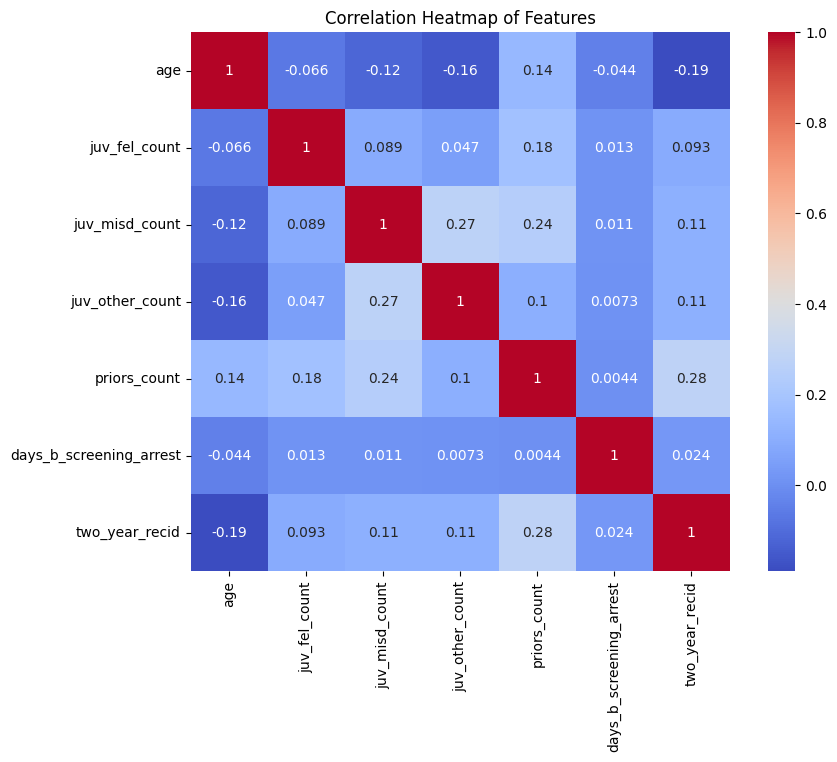

In [12]:

num_data = data._get_numeric_data()
corr = num_data.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    square=True
)
plt.title("Correlation Heatmap of Features")
plt.show()


In [13]:
data.isnull().sum()

sex                          0
age                          0
race                         0
juv_fel_count                0
juv_misd_count               0
juv_other_count              0
priors_count                 0
days_b_screening_arrest    307
c_charge_degree              0
two_year_recid               0
dtype: int64

In [14]:
data['days_b_screening_arrest'] = data['days_b_screening_arrest'].fillna(
    data['days_b_screening_arrest'].median()
)

In [15]:
data.isnull().sum()

sex                        0
age                        0
race                       0
juv_fel_count              0
juv_misd_count             0
juv_other_count            0
priors_count               0
days_b_screening_arrest    0
c_charge_degree            0
two_year_recid             0
dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['race'] = le.fit_transform(data['race'])

In [17]:
# data.sample(5)

In [18]:
x = data.drop(columns=['race', 'sex', 'two_year_recid'])
y= data['two_year_recid']
A= data[['race', 'sex']].values

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test, A_train, A_test = train_test_split(
    x, y,A,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)
base_model.fit(x_train, y_train)

y_pred = base_model.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6943866943866944


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.80      0.75       823
           1       0.68      0.55      0.61       620

    accuracy                           0.69      1443
   macro avg       0.69      0.68      0.68      1443
weighted avg       0.69      0.69      0.69      1443



DETECT BIASNESS------------>>

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

features = ['age','priors_count','juv_fel_count',
            'c_charge_degree','days_b_screening_arrest','race',
    'sex',]

X = data[features]
y = data['two_year_recid']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


# A Decision Tree classifier is trained as the baseline prediction model using criminal history and demographic features.

Accuracy: 0.6859122401847575


In [121]:
results = X_test.copy()

results['prediction'] = y_pred
results['actual'] = y_test.values

results['race'] = data.loc[X_test.index,'race']
results['sex'] = data.loc[X_test.index,'sex']


In [122]:
# Demographic Parity Test
race_bias = results.groupby('race')['prediction'].mean()
sex_bias = results.groupby('sex')['prediction'].mean()

print("Prediction rate by race")
print(race_bias)

print("Prediction rate by sex")
print(sex_bias)
# prediction probability differs across groups ------> algorithmic bias exists.

Prediction rate by race
race
0    0.481115
1    0.166667
2    0.274324
3    0.245902
4    0.666667
5    0.297521
Name: prediction, dtype: float64
Prediction rate by sex
sex
0    0.183879
1    0.423643
Name: prediction, dtype: float64


In [123]:
# African-American → 0
# Native American → 4

# RACE 4 has higher prediction avg .....


# Asian → 1
# Caucasian → 2
# Hispanic → 3
# Other → 5

In [124]:
# female --> 1
# male ----> 0
#here,,, prediction avg. difference is indicating biasness on the basis of gender

In [102]:
from sklearn.feature_selection import mutual_info_classif

X_bias = data[['race','sex']]
y_bias = data['two_year_recid']

mi_scores = mutual_info_classif(X_bias, y_bias, random_state=42)

mi_df = pd.DataFrame({
    'Sensitive Feature': X_bias.columns,
    'Mutual Information': mi_scores
})

print(mi_df)

  Sensitive Feature  Mutual Information
0              race            0.005233
1               sex            0.009525


In [103]:
from sklearn.feature_selection import mutual_info_classif

X = data[['age', 'priors_count', 'juv_fel_count', 
          'c_charge_degree', 'days_b_screening_arrest']]
y = data['two_year_recid']
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': mi_scores
}).sort_values(by='Mutual_Information', ascending=False)

mi_df

,Feature,Mutual_Information
1,priors_count,0.055865
0,age,0.016016
4,days_b_screening_arrest,0.015384
3,c_charge_degree,0.002245
2,juv_fel_count,0.001696


In [104]:
data[['race','priors_count']].corr()

,race,priors_count
race,1.000000,-0.191415
priors_count,-0.191415,1.000000


In [105]:
# Proxy Bias::
# Sensitive attribute influences other features...

# race vs priors_count = -0.191
# race is correlated with criminal history variables.
# race → priors_count → prediction

In [106]:
data[['sex','priors_count']].corr()

,sex,priors_count
sex,1.000000,0.119556
priors_count,0.119556,1.000000


In [107]:
# Proxy Bias::
# Sensitive attribute influences other features...

# sex vs priors_count = 0.12
# sex is correlated with criminal history variables.
# sex → priors_count → prediction

In [108]:
#calculation of false positive....
# False positive = predicted criminal but actually not.


from sklearn.metrics import confusion_matrix

for r in results['race'].unique():
    
    subset = results[results['race']==r]
    
    tn,fp,fn,tp = confusion_matrix(
        subset['actual'],
        subset['prediction']
    ).ravel()
    
    fpr = fp/(fp+tn)
    
    print("Race",r,"FPR:",fpr)

Race 2 FPR: 0.17672413793103448
Race 0 FPR: 0.28383458646616544
Race 5 FPR: 0.189873417721519
Race 3 FPR: 0.176
Race 4 FPR: 0.5
Race 1 FPR: 0.2


In [109]:
# Disparate Impact
# DI::
# ≈1  ------>   fair
# <0.8 ------>	biased
# >1.25 ------>	biased


p1 = results[results['race']==1]['prediction'].mean()
p0 = results[results['race']==0]['prediction'].mean()

di = p1/p0
print("Disparate Impact for race:",di)

p2 = results[results['sex']==1]['prediction'].mean()
p3 = results[results['sex']==0]['prediction'].mean()

di1 = p2/p3
print("Disparate Impact for sex:",di1)


Disparate Impact for race: 0.346417445482866
Disparate Impact for sex: 2.303918985929461


In [110]:
# disparate Impact for race: 0.3388177940280317
# Disparate Impact for sex: 1.50591037402964
#  biasness is clear....

Bias Reduction Method 1 ---> Removing Sensitive Attributes------>(Sensitive attributes such as race and sex were removed from the feature set to prevent the model from directly learning discriminatory patterns.)

In [111]:
features_fair = ['age','priors_count','juv_fel_count',
                 'c_charge_degree','days_b_screening_arrest']

X_fair = data[features_fair]
y = data['two_year_recid']

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_fair,y,test_size=0.3,random_state=42
)

from sklearn.tree import DecisionTreeClassifier

fair_model = DecisionTreeClassifier(max_depth=4)

fair_model.fit(X_train,y_train)

y_pred_fair = fair_model.predict(X_test)

In [112]:
results_fair = X_test.copy()

results_fair['prediction'] = y_pred_fair
results_fair['race'] = data.loc[X_test.index,'race']

results_fair.groupby('race')['prediction'].mean()

race
0    0.491906
1    0.166667
2    0.279730
3    0.251366
4    0.666667
5    0.305785
Name: prediction, dtype: float64

Bias Reduction Method 2 —----> Reweighing------>(Give equal importance to all demographic groups.)


In [126]:
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight(
    class_weight="balanced",
    y=data['two_year_recid']
)

model_weighted = DecisionTreeClassifier(max_depth=4)

model_weighted.fit(X_train,y_train,sample_weight=weights[X_train.index])

y_pred_weighted = model_weighted.predict(X_test)


results_fair = X_test.copy()

results_fair['prediction'] = y_pred_fair
results_fair['race'] = data.loc[X_test.index,'race']

results_fair.groupby('race')['prediction'].mean()

race
0    0.491906
1    0.166667
2    0.279730
3    0.251366
4    0.666667
5    0.305785
Name: prediction, dtype: float64

Bias Reduction Method 3 ------> Fairness Constraint---->(logistic regression is more stable.)

In [119]:
from sklearn.linear_model import LogisticRegression

fair_lr = LogisticRegression()

fair_lr.fit(X_train,y_train)

y_pred_lr = fair_lr.predict(X_test)
results_fair = X_test.copy()

results_fair['prediction'] = y_pred_fair
results_fair['race'] = data.loc[X_test.index,'race']

results_fair.groupby('race')['prediction'].mean()

race
0    0.491906
1    0.166667
2    0.279730
3    0.251366
4    0.666667
5    0.305785
Name: prediction, dtype: float64

In [129]:
features_fair = ['age',
                 'juv_fel_count',
                 'c_charge_degree',
                 'days_b_screening_arrest']

X = data[features_fair]
y = data['two_year_recid']
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

from sklearn.tree import DecisionTreeClassifier
model_proxy_removed = DecisionTreeClassifier(max_depth=4)
model_proxy_removed.fit(X_train,y_train)
y_pred_proxy = model_proxy_removed.predict(X_test)



results_proxy = X_test.copy()
results_proxy['prediction'] = y_pred_proxy
results_proxy['race'] = data.loc[X_test.index,'race']
results_proxy.groupby('race')['prediction'].mean()

race
0    0.544964
1    0.333333
2    0.343243
3    0.387978
4    1.000000
5    0.429752
Name: prediction, dtype: float64

In [130]:
results_proxy = X_test.copy()
results_proxy['prediction'] = y_pred_proxy
results_proxy['sex'] = data.loc[X_test.index,'sex']
results_proxy.groupby('sex')['prediction'].mean()

sex
0    0.382872
1    0.472851
Name: prediction, dtype: float64

In [132]:
# Disparate Impact
# DI::
# ≈1  ------>   fair
# <0.8 ------>	biased
# >1.25 ------>	biased

results_proxy = X_test.copy()

results_proxy['prediction'] = y_pred_proxy
results_proxy['race'] = data.loc[X_test.index,'race']
results_proxy['sex'] = data.loc[X_test.index,'sex']

p1 = results_proxy[results_proxy['race']==1]['prediction'].mean()
p0 = results_proxy[results_proxy['race']==0]['prediction'].mean()
di_race = p1/p0
print(di_race)

p2 = results_proxy[results_proxy['sex']==1]['prediction'].mean()
p3 = results_proxy[results_proxy['sex']==0]['prediction'].mean()
di_sex = p2/p3
print(di_sex)

0.6116611661166116
1.2350113122171946


COMPARISON----------->>

In [137]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_proxy)
print(acc)

0.6064665127020785


In [139]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_proxy))

              precision    recall  f1-score   support

           0       0.65      0.63      0.64      1207
           1       0.55      0.57      0.56       958

    accuracy                           0.61      2165
   macro avg       0.60      0.60      0.60      2165
weighted avg       0.61      0.61      0.61      2165



In [141]:
comparison = {
    "Model":["Baseline","Proxy Removed"],
    "DI_race":[di, di_race],
    "DI_sex":[di1, di_sex]
}

import pandas as pd
fairness_table = pd.DataFrame(comparison)
print(fairness_table)

           Model   DI_race    DI_sex
0       Baseline  0.346417  2.303919
1  Proxy Removed  0.611661  1.235011


In [133]:
# comparison::
# before::
# Disparate Impact for race: 0.346417445482866(highly biased)
# Disparate Impact for sex: 2.303918985929461(highly biased)

# after::
# Disparate Impact for race: 0.6116611661166116 <0.8 (biasness reduced)
# Disparate Impact for sex: 1.2350113122171946 <1.25  (unbiased...)

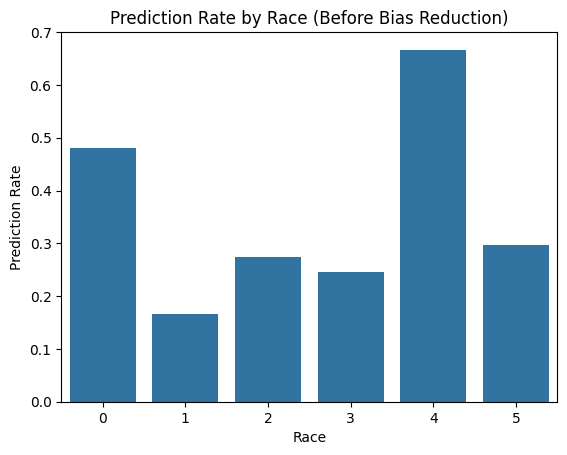

In [144]:
race_rates_before = results.groupby('race')['prediction'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=race_rates_before.index, y=race_rates_before.values)

plt.xlabel("Race")
plt.ylabel("Prediction Rate")
plt.title("Prediction Rate by Race (Before Bias Reduction)")

plt.show()

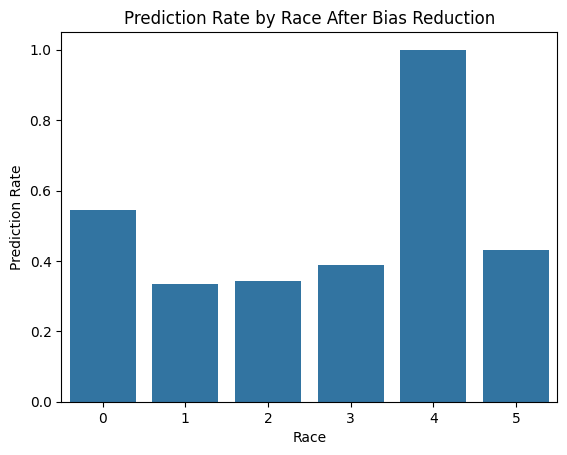

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

race_rates = results_proxy.groupby('race')['prediction'].mean()

sns.barplot(x=race_rates.index, y=race_rates.values)

plt.xlabel("Race")
plt.ylabel("Prediction Rate")
plt.title("Prediction Rate by Race After Bias Reduction")

plt.show()

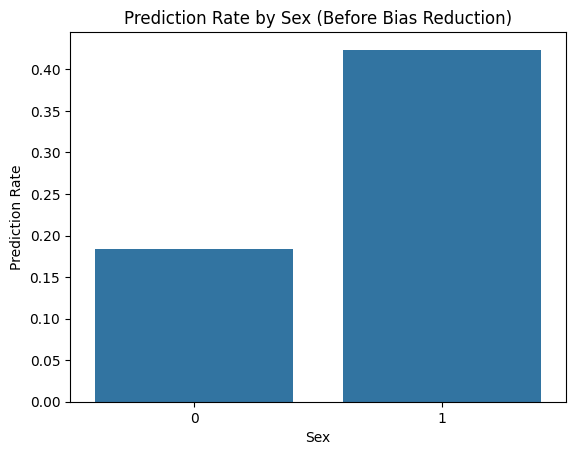

In [146]:
sex_rates_before = results.groupby('sex')['prediction'].mean()

sns.barplot(x=sex_rates_before.index, y=sex_rates_before.values)

plt.xlabel("Sex")
plt.ylabel("Prediction Rate")
plt.title("Prediction Rate by Sex (Before Bias Reduction)")

plt.show()

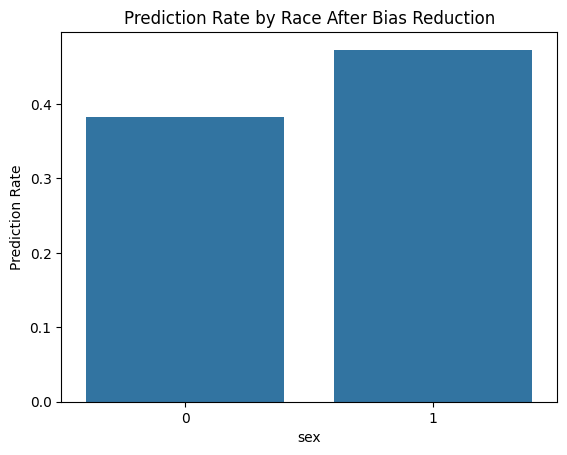

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

sex_rates = results_proxy.groupby('sex')['prediction'].mean()

sns.barplot(x=sex_rates.index, y=sex_rates.values)

plt.xlabel("sex")
plt.ylabel("Prediction Rate")
plt.title("Prediction Rate by Race After Bias Reduction")

plt.show()

In [134]:
# Dataset
#    
# Preprocessing
#    
# Bias Detection
# (Mutual Information + Correlation)
#    
# Baseline Model
#    
# Fairness Evaluation
#    
# Bias Mitigation
# (Remove Proxy Features)
#    
# Fair Model & comparison

In [135]:
# Mutual Information -------> low direct bias
# Correlation  -------------> sex & race linked to priors_count

# Removing sensitive attributes ------> no change
# Removing proxy features ------> bias reduced